# Eksplorasi Data (EDA) — PRDECT-ID

Notebook ini mengeksplorasi dataset **PRDECT-ID** (ulasan produk Tokopedia) sebelum pemodelan:
distribusi label sentimen & emosi, panjang teks, dan contoh data. Temuan di sini menjadi dasar
keputusan pra-pemrosesan & evaluasi (lihat README).

Jalankan dari root proyek: `jupyter notebook notebooks/01_eksplorasi_data.ipynb`

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path('..') / 'data' / 'prdect_id.csv'
df = pd.read_csv(DATA)
print('Bentuk data:', df.shape)
df.head()

Bentuk data: (5400, 11)


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


In [2]:
# Kolom & nilai kosong
print('Kolom:', list(df.columns))
print('\nJumlah nilai kosong per kolom penting:')
print(df[['Customer Review', 'Sentiment', 'Emotion']].isna().sum())

Kolom: ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion']

Jumlah nilai kosong per kolom penting:
Customer Review    0
Sentiment          0
Emotion            0
dtype: int64


## Distribusi label Sentimen

Sentiment
Negative    2821
Positive    2579
Name: count, dtype: int64


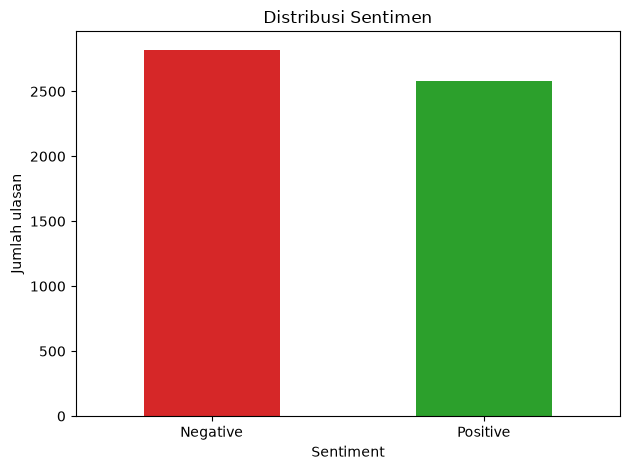

In [3]:
sent = df['Sentiment'].value_counts()
print(sent)
sent.plot(kind='bar', color=['#d62728', '#2ca02c'], title='Distribusi Sentimen')
plt.ylabel('Jumlah ulasan'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

Sentimen relatif **seimbang** (Negative vs Positive). Karena itu *accuracy* cukup informatif
untuk tugas sentimen.

## Distribusi label Emosi

Emotion
Happy      1770
Sadness    1202
Fear        920
Love        809
Anger       699
Name: count, dtype: int64


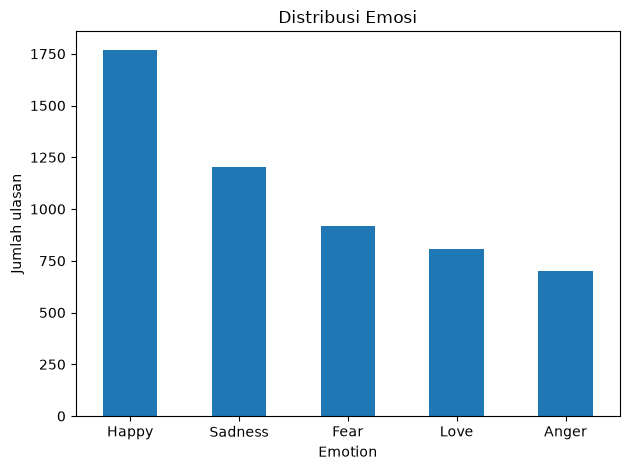

In [4]:
emo = df['Emotion'].value_counts()
print(emo)
emo.plot(kind='bar', color='#1f77b4', title='Distribusi Emosi')
plt.ylabel('Jumlah ulasan'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

Emosi **tidak seimbang** (Happy dominan, Anger paling sedikit). Implikasinya: gunakan
**macro-F1** (bukan hanya accuracy) dan `class_weight='balanced'` saat melatih model emosi.

## Panjang teks ulasan

count    5400.000000
mean       16.095000
std        15.647181
min         1.000000
25%         7.000000
50%        12.000000
75%        20.000000
max       184.000000
Name: Customer Review, dtype: float64


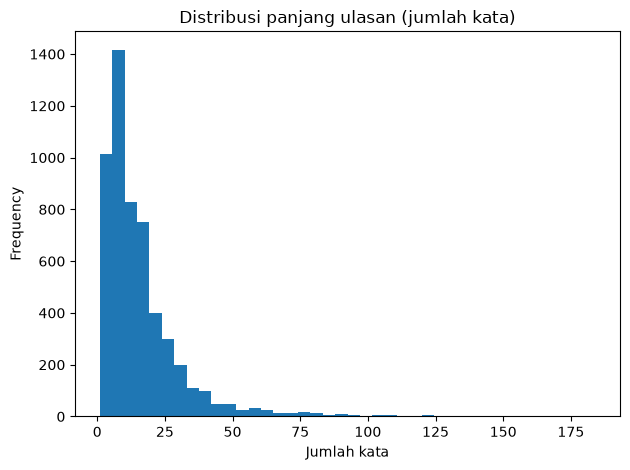

In [5]:
lengths = df['Customer Review'].astype(str).str.split().apply(len)
print(lengths.describe())
lengths.plot(kind='hist', bins=40, title='Distribusi panjang ulasan (jumlah kata)')
plt.xlabel('Jumlah kata'); plt.tight_layout(); plt.show()

## Contoh ulasan per kelas

In [6]:
for emosi in df['Emotion'].unique():
    contoh = df[df['Emotion'] == emosi]['Customer Review'].iloc[0]
    print(f'[{emosi}] {contoh[:120]}')
    print('-' * 70)

[Happy] Alhamdulillah berfungsi dengan baik. Packaging aman. Respon cepat dan ramah. Seller dan kurir amanah
----------------------------------------------------------------------
[Sadness] Sangat kecewa. Baru 4 bulan scroll sudah rusak.
----------------------------------------------------------------------
[Anger] Sangat mengecewakan, barang yg dikirim tidak sesuai konfirmasi, sampai harus bolak-balik 2 kali, saya harus nanggung 6 X
----------------------------------------------------------------------
[Love] Bagus banget keyboardnya. Packing sangat aman karena double kardus. Warna juga keren.
----------------------------------------------------------------------
[Fear] BAHAN DARI PLASTIK DAN TIDAK KUAT JUGA BUAT MENOPANG LAPTOP.INI SIH KUATNYA BUAT TABLET GAISSS. LEBIH BAIK JANGAN BELI Y
----------------------------------------------------------------------


## Ringkasan temuan

1. **5.400 ulasan**, tidak ada nilai kosong pada kolom teks/label.
2. **Sentimen seimbang** -> accuracy memadai.
3. **Emosi tidak seimbang** -> pakai macro-F1 + `class_weight='balanced'`.
4. Ulasan umumnya **pendek** -> TF-IDF dengan unigram+bigram cocok.
5. Langkah pra-pemrosesan (lihat `src/preprocessing.py`): case folding, hapus URL/angka/simbol,
   hapus stopword (kecuali kata negasi), stemming Sastrawi.